In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
df=pd.read_csv("C:\\Users\\Shahzadi\\Desktop\\ml\\dataset1.csv")
df.head()

,id,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1


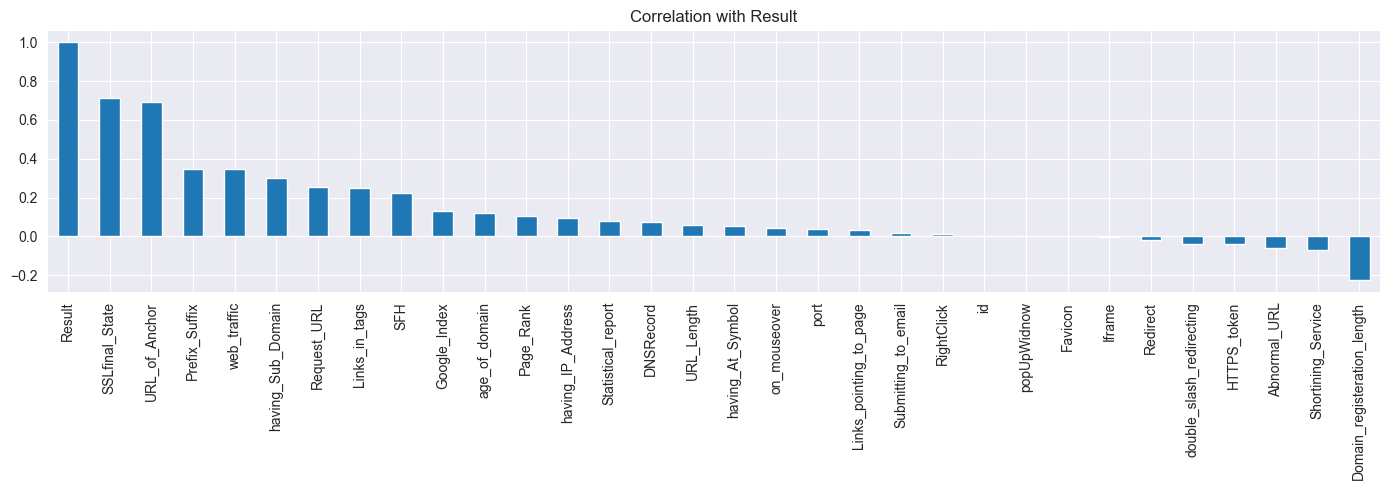

In [3]:
corr = df.corr(numeric_only=True)
corr['Result'].sort_values(ascending=False).plot(kind='bar', figsize=(14,5))
plt.title("Correlation with Result")
plt.tight_layout()
plt.show()

In [4]:
df.drop(columns=['id','Abnormal_URL','HTTPS_token','Favicon','Iframe',
                 'popUpWidnow','Page_Rank','RightClick','on_mouseover'],
        inplace=True, errors='ignore')

In [5]:
df['Result'] = df['Result'].map({-1: 0, 1: 1})
X = df.drop('Result', axis=1)
y = df['Result']
print("X shape:", X.shape)
print("Label counts:\n", y.value_counts())

X shape: (11055, 22)
Label counts:
 Result
1    6157
0    4898
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score

# Define all 7 models — brackets () on every model!
models = [
    ('Logistic Regression',  LogisticRegression(max_iter=1000, random_state=42)),
    ('SVM',                  SVC(kernel='rbf', probability=True, random_state=42)),
    ('Decision Tree',        DecisionTreeClassifier(max_depth=10, random_state=42)),
    ('Random Forest',        RandomForestClassifier(n_estimators=100, random_state=42)),
    ('KNN',                  KNeighborsClassifier(n_neighbors=5)),
    ('XGBoost',              XGBClassifier(n_estimators=100, random_state=42,
                                           eval_metric='logloss', verbosity=0)),
    ('CatBoost',             CatBoostClassifier(iterations=100, random_seed=42,
                                                verbose=0)),
]

results = []
best_model_obj  = None
best_model_name = ""
best_accuracy   = 0.0

print(f"{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'CV Mean':>9}")
print("=" * 72)

for name, model in models:
    # Build pipeline with scaler + model
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  model)
    ])

    # Train
    pipeline.fit(x_train, y_train)

    # Test accuracy
    y_pred   = pipeline.predict(x_test)
    acc      = accuracy_score(y_test, y_pred)
    prec     = precision_score(y_test, y_pred)
    rec      = recall_score(y_test, y_pred)
    f1       = f1_score(y_test, y_pred)

    # Cross validation (5-fold)
    cv_scores = cross_val_score(pipeline, x_train, y_train, cv=5)
    cv_mean   = cv_scores.mean()

    print(f"{name:<22} {acc*100:>8.2f}% {prec*100:>9.2f}% {rec*100:>7.2f}% {f1*100:>7.2f}% {cv_mean*100:>8.2f}%")
    results.append({
        'Model':     name,
        'Accuracy':  round(acc * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall':    round(rec * 100, 2),
        'F1 Score':  round(f1 * 100, 2),
        'CV Mean':   round(cv_mean * 100, 2)
    })
    if acc > best_accuracy:
        best_accuracy   = acc
        best_model_obj  = pipeline
        best_model_name = name

print("=" * 72)
print(f"\nBest model: {best_model_name} — {best_accuracy*100:.2f}%")

Model                   Accuracy  Precision   Recall       F1   CV Mean
Logistic Regression       92.85%     92.21%   95.21%   93.69%    92.97%
SVM                       95.12%     93.90%   97.56%   95.70%    94.86%
Decision Tree             95.16%     95.77%   95.53%   95.65%    94.44%
Random Forest             97.01%     96.94%   97.73%   97.33%    96.63%
KNN                       94.89%     94.37%   96.59%   95.46%    93.60%
XGBoost                   97.15%     96.87%   98.05%   97.46%    96.77%
CatBoost                  96.79%     96.47%   97.81%   97.14%    96.64%

Best model: XGBoost — 97.15%


In [8]:
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
results_df = results_df.reset_index(drop=True)
results_df.index += 1
print(results_df.to_string())
results_df.to_csv('model_comparison_results.csv', index=False)
print("\nResults saved to model_comparison_results.csv")

                 Model  Accuracy  Precision  Recall  F1 Score  CV Mean
1              XGBoost     97.15      96.87   98.05     97.46    96.77
2        Random Forest     97.01      96.94   97.73     97.33    96.63
3             CatBoost     96.79      96.47   97.81     97.14    96.64
4        Decision Tree     95.16      95.77   95.53     95.65    94.44
5                  SVM     95.12      93.90   97.56     95.70    94.86
6                  KNN     94.89      94.37   96.59     95.46    93.60
7  Logistic Regression     92.85      92.21   95.21     93.69    92.97

Results saved to model_comparison_results.csv


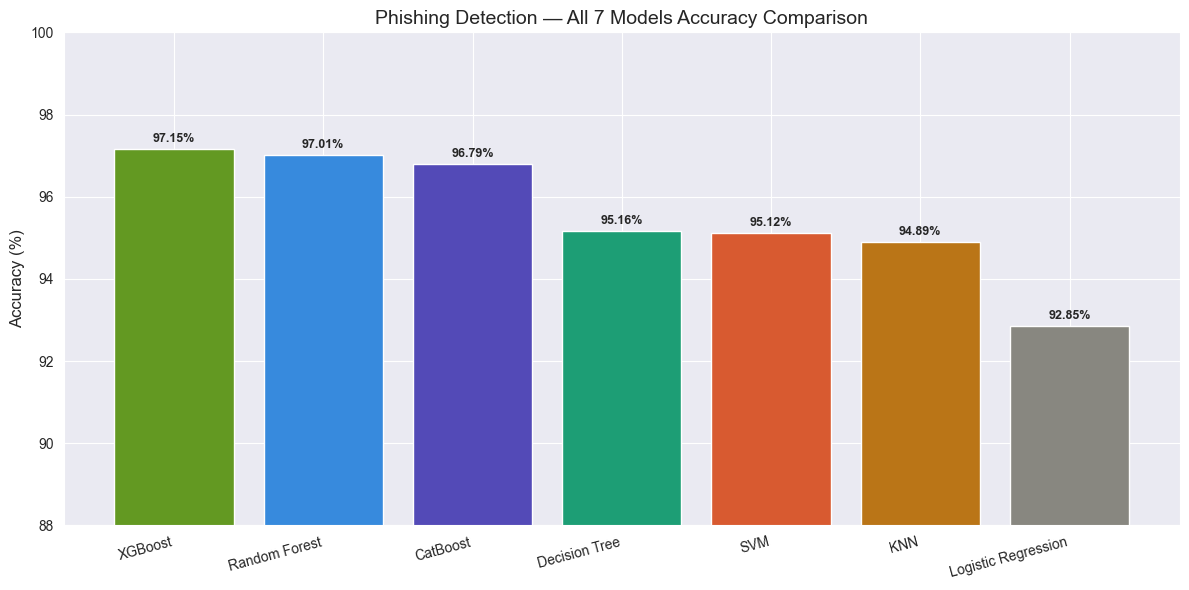

Chart saved as model_comparison.png


In [9]:
plt.figure(figsize=(12, 6))
colors = ['#639922','#378ADD','#534AB7','#1D9E75','#D85A30','#BA7517','#888780']
bars = plt.bar(results_df['Model'], results_df['Accuracy'], color=colors[:len(results_df)])
plt.ylim(88, 100)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Phishing Detection — All 7 Models Accuracy Comparison', fontsize=14)
plt.xticks(rotation=15, ha='right')
for bar, acc in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{acc}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Chart saved as model_comparison.png")

In [10]:
joblib.dump(best_model_obj, 'best_model.pkl')
print(f"Best model saved: {best_model_name} — {best_accuracy*100:.2f}%")
print("File: best_model.pkl")

Best model saved: XGBoost — 97.15%
File: best_model.pkl


In [11]:
import re
from urllib.parse import urlparse

# List of known URL shorteners
SHORTENERS = ['bit.ly', 'goo.gl', 'tinyurl.com', 'ow.ly',
              't.co', 'is.gd', 'buff.ly', 'adf.ly', 'short.link',
              'rebrand.ly', 'cutt.ly', 'rb.gy']

def extract_features(url):
    parsed = urlparse(url)
    netloc = parsed.netloc.lower().replace('www.', '')
    path   = parsed.path
    return {
        'having_IP_Address'           : 1 if re.match(r'\d+\.\d+\.\d+\.\d+', netloc) else -1,
        'URL_Length'                  : 1 if len(url) < 54 else (-1 if len(url) > 75 else 0),
        'Shortining_Service'          : -1 if any(s in netloc for s in SHORTENERS) else 1,
        'having_At_Symbol'            : -1 if '@' in url else 1,
        'double_slash_redirecting'    : -1 if '//' in path else 1,
        'Prefix_Suffix'               : -1 if '-' in netloc else 1,
        'having_Sub_Domain'           : -1 if netloc.count('.') > 2 else (0 if netloc.count('.') == 2 else 1),
        'SSLfinal_State'              : 1 if parsed.scheme == 'https' else -1,
        'Domain_registeration_length' : 0,
        'port'                        : -1 if ':' in netloc else 1,
        'Request_URL'                 : 1,
        'URL_of_Anchor'               : 0,
        'Links_in_tags'               : 1,
        'SFH'                         : 1,
        'Submitting_to_email'         : -1 if 'mailto:' in url else 1,
        'Redirect'                    : 0,
        'age_of_domain'               : 0,
        'DNSRecord'                   : 0,
        'web_traffic'                 : 0,
        'Google_Index'                : 1,
        'Links_pointing_to_page'      : 0,
        'Statistical_report'          : -1 if any(s in netloc for s in SHORTENERS) else 1,
    }

# ── Updated check function with shortener override ────────
def check_url_all_models(url):
    parsed = urlparse(url)
    netloc = parsed.netloc.lower().replace('www.', '')

    # Special rule — if URL is a shortener, flag immediately
    is_shortener = any(s in netloc for s in SHORTENERS)

    features   = extract_features(url)
    feat_cols  = x_train.columns.tolist()
    input_data = pd.DataFrame([features])[feat_cols]

    print("\n" + "="*65)
    print(f"  URL: {url}")
    if is_shortener:
        print(f"  WARNING: This is a URL shortener — real destination is hidden!")
    print("="*65)
    print(f"  {'Model':<22} {'Result':<22} {'Confidence':>10}")
    print("-"*65)

    for name, pipeline in all_pipelines.items():
        pred       = pipeline.predict(input_data)[0]
        confidence = pipeline.predict_proba(input_data).max() * 100
        result     = "LEGITIMATE" if pred == 1 else "PHISHING"

        # Override — if shortener, mark as suspicious regardless
        if is_shortener:
            result     = "SUSPICIOUS (shortener)"
            confidence = 100.0

        elif confidence < 70:
            result = "SUSPICIOUS"

        print(f"  {name:<22} {result:<22} {confidence:>9.1f}%")

    print("="*65)
    if is_shortener:
        print("  ADVICE: Never trust shortened URLs — always expand them first.")
    print()

# ── Test ──────────────────────────────────────────────────
url = input("\nPaste any URL to check: ")
check_url_all_models(url)



  URL: https://www.linkedin.com/feed/
  Model                  Result                 Confidence
-----------------------------------------------------------------


NameError: name 'all_pipelines' is not defined